# Another method

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from movement.io import load_dataset
from movement.filtering import (
    filter_by_confidence,
    interpolate_over_time,
    rolling_filter,
)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from scipy.signal import find_peaks

In [22]:
# Change this path if needed
filename = (
    "/Users/margotrefuge/osss/data/fly_top_view/"
    "labels.v001-cs-01.000_cs-1-trial 0.analysis.h5"
)
FPS = None
CONFIDENCE_THRESHOLD = 0.70

# Only interpolate gaps <= 3 frames
MAX_INTERPOLATION_GAP = 3

# Median rolling filter
SMOOTHING_WINDOW = 5
MIN_PERIODS = 2
N_CLUSTERS = 2
MIN_CLUSTER_DURATION = 3
PEAK_PROMINENCE = 10
PEAK_DISTANCE = 5


In [23]:
if FPS is None:

    ds = load_dataset(
        filename,
        source_software="SLEAP"
    )

else:

    ds = load_dataset(
        filename,
        source_software="SLEAP",
        fps=FPS
    )


print(ds)

print("\nKeypoints:")
print(ds.keypoint.values)

print("\nNumber of frames:")
print(ds.sizes["time"])

<xarray.Dataset> Size: 23kB
Dimensions:     (time: 196, space: 2, keypoint: 9, individual: 1)
Coordinates:
  * time        (time) int64 2kB 0 1 2 3 4 5 6 7 ... 189 190 191 192 193 194 195
  * space       (space) <U1 8B 'x' 'y'
  * keypoint    (keypoint) <U6 216B 'head' 'thorax' 'belly' ... 'RM' 'LR' 'RR'
  * individual  (individual) <U4 16B 'id_0'
Data variables:
    position    (time, space, keypoint, individual) float32 14kB 2.082e+03 .....
    confidence  (time, keypoint, individual) float32 7kB 0.8824 ... 0.7143
Attributes:
    source_software:  SLEAP
    ds_type:          poses
    time_unit:        frames
    source_file:      /Users/margotrefuge/osss/data/fly_top_view/labels.v001-...

Keypoints:
['head' 'thorax' 'belly' 'LF' 'RF' 'LM' 'RM' 'LR' 'RR']

Number of frames:
196


In [24]:
required_keypoints = ["LF", "thorax", "head"]

available_keypoints = list(ds.keypoint.values)

for keypoint in required_keypoints:

    if keypoint not in available_keypoints:

        raise ValueError(
            f"Required keypoint '{keypoint}' was not found."
        )


print("\nRequired keypoints found:")
print(required_keypoints)


Required keypoints found:
['LF', 'thorax', 'head']


In [25]:
position_filtered = filter_by_confidence(
    ds.position,
    ds.confidence,
    threshold=CONFIDENCE_THRESHOLD,
    print_report=True
)

Missing points (marked as NaN) in input:

keypoint                LF              RF              LM               RM               LR             RR
individual                                                                                                 
id_0        19/196 (9.69%)  11/196 (5.61%)  14/196 (7.14%)  33/196 (16.84%)  22/196 (11.22%)  7/196 (3.57%)
Missing points (marked as NaN) in output:

keypoint               head           thorax            belly                LF                RF               LM                RM                LR                RR
individual                                                                                                                                                              
id_0        50/196 (25.51%)  55/196 (28.06%)  56/196 (28.57%)  116/196 (59.18%)  103/196 (52.55%)  97/196 (49.49%)  119/196 (60.71%)  156/196 (79.59%)  111/196 (56.63%)


In [26]:
position_interpolated = interpolate_over_time(
    position_filtered,
    method="linear",
    max_gap=MAX_INTERPOLATION_GAP,
    print_report=True
)

Missing points (marked as NaN) in input:

keypoint               head           thorax            belly                LF                RF               LM                RM                LR                RR
individual                                                                                                                                                              
id_0        50/196 (25.51%)  55/196 (28.06%)  56/196 (28.57%)  116/196 (59.18%)  103/196 (52.55%)  97/196 (49.49%)  119/196 (60.71%)  156/196 (79.59%)  111/196 (56.63%)
Missing points (marked as NaN) in output:

keypoint           thorax          belly               LF               RF               LM               RM                LR               RR
individual                                                                                                                                     
id_0        5/196 (2.55%)  4/196 (2.04%)  80/196 (40.82%)  55/196 (28.06%)  52/196 (26.53%)  81/196 (41.33%)  140/196 (7

In [27]:
position_smooth = rolling_filter(
    position_interpolated,
    window=SMOOTHING_WINDOW,
    statistic="median",
    min_periods=MIN_PERIODS
)

In [28]:
position_processed = position_smooth.where(
    ~position_interpolated.isnull()
)

Head, thorax and head position

In [29]:
lf = (
    position_processed
    .sel(keypoint="LF")
    .squeeze()
)

thorax = (
    position_processed
    .sel(keypoint="thorax")
    .squeeze()
)

head = (
    position_processed
    .sel(keypoint="head")
    .squeeze()
)

Space position

In [30]:
lf_xy = (
    lf
    .transpose("time", "space")
    .values
)

thorax_xy = (
    thorax
    .transpose("time", "space")
    .values
)

head_xy = (
    head
    .transpose("time", "space")
    .values
)


In [31]:
n_frames = lf_xy.shape[0]

frames = np.arange(n_frames)

time_values = lf.time.values


print("\nLF array shape:")
print(lf_xy.shape)



LF array shape:
(196, 2)


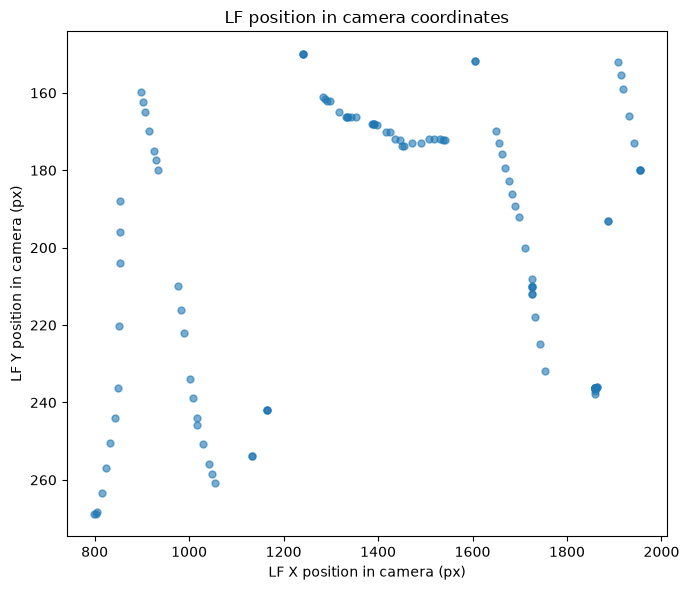

In [32]:
plt.figure(figsize=(7, 6))

plt.scatter(
    lf_xy[:, 0],
    lf_xy[:, 1],
    alpha=0.6,
    s=25
)

plt.xlabel("LF X position in camera (px)")
plt.ylabel("LF Y position in camera (px)")

plt.title(
    "LF position in camera coordinates"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

Paw position ~ thorax 

In [33]:
lf_relative = lf_xy - thorax_xy

Body relative scatter plot

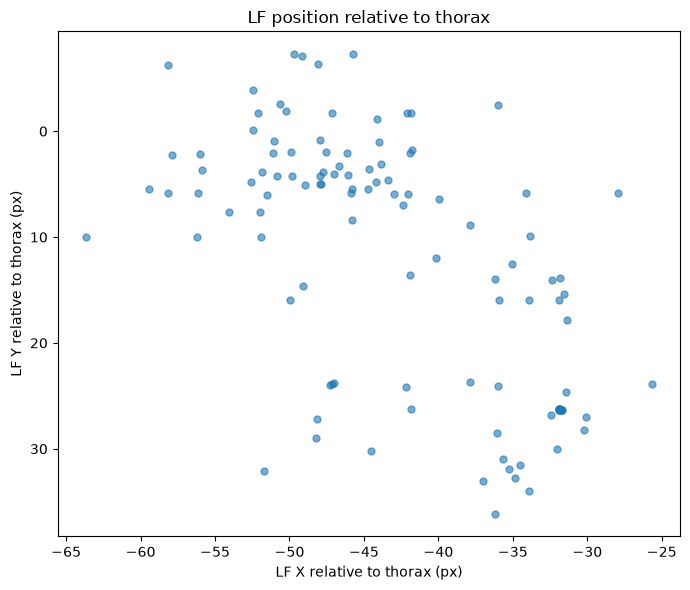

In [34]:
plt.figure(figsize=(7, 6))

plt.scatter(
    lf_relative[:, 0],
    lf_relative[:, 1],
    alpha=0.6,
    s=25
)

plt.xlabel("LF X relative to thorax (px)")
plt.ylabel("LF Y relative to thorax (px)")

plt.title(
    "LF position relative to thorax"
)

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

Fly body axe

In [35]:
body_axis = head_xy - thorax_xy

# Length of body-axis vector for each frame

body_axis_length = np.linalg.norm(
    body_axis,
    axis=1
)

# Avoid division by zero

body_axis_length[
    body_axis_length == 0
] = np.nan

# Unit vector pointing forward

body_axis_unit = (
    body_axis /
    body_axis_length[:, None]
)

Lateral vector / perpandiculaire

In [36]:
lateral_axis_unit = np.column_stack(
    [
        -body_axis_unit[:, 1],
        body_axis_unit[:, 0]
    ]
)

LF position --> axe body

In [37]:
lf_fore_aft = np.sum(
    lf_relative * body_axis_unit,
    axis=1
)


lf_lateral = np.sum(
    lf_relative * lateral_axis_unit,
    axis=1
)


Scatter plot

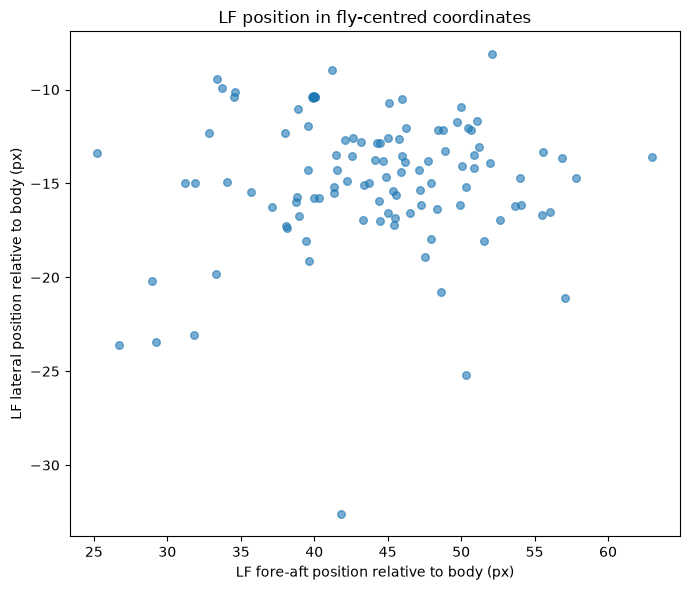

In [38]:
valid_body = (
    np.isfinite(lf_fore_aft)
    &
    np.isfinite(lf_lateral)
)


plt.figure(figsize=(7, 6))

plt.scatter(
    lf_fore_aft[valid_body],
    lf_lateral[valid_body],
    alpha=0.6,
    s=30
)

plt.xlabel(
    "LF fore-aft position relative to body (px)"
)

plt.ylabel(
    "LF lateral position relative to body (px)"
)

plt.title(
    "LF position in fly-centred coordinates"
)

plt.tight_layout()

plt.show()

Kmeans clustering (wsbim1322)

# Can the LF XY positions be separated into two preferred states? 
Extended - not 

In [39]:
X = np.column_stack(
    [
        lf_fore_aft,
        lf_lateral
    ]
)

valid_cluster = np.all(
    np.isfinite(X),
    axis=1
)


X_valid = X[valid_cluster]


# Safety check

if len(X_valid) < N_CLUSTERS:

    raise ValueError(
        "Not enough valid frames for clustering."
    )


kmeans = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,
    n_init=20
)


labels_valid = kmeans.fit_predict(
    X_valid
)


Labeling

In [40]:
cluster_labels = np.full(
    n_frames,
    -1,
    dtype=int
)


cluster_labels[
    valid_cluster
] = labels_valid

Centroid

In [41]:
centroids = []

for cluster in range(N_CLUSTERS):

    cluster_points = X_valid[
        labels_valid == cluster
    ]

    centroid = np.mean(
        cluster_points,
        axis=0
    )

    centroids.append(
        centroid
    )


centroids = np.asarray(
    centroids
)


print("\nCluster centroids:")

for i, centroid in enumerate(centroids):

    print(
        f"Cluster {i}: "
        f"fore-aft = {centroid[0]:.2f}, "
        f"lateral = {centroid[1]:.2f}"
    )


Cluster centroids:
Cluster 0: fore-aft = 49.13, lateral = -14.73
Cluster 1: fore-aft = 37.97, lateral = -14.38


Distance : It quantifies how spatially separated the two clusters are.

In [42]:
if N_CLUSTERS == 2:

    centroid_distance = np.linalg.norm(
        centroids[0] - centroids[1]
    )

    print(
        "\nDistance between centroids:",
        f"{centroid_distance:.2f} px"
    )


Distance between centroids: 11.17 px


Rough mesure of clustering sep
- close to 1 = well separated
- around 0    = overlapping
- below 0     = poor assignment

In [43]:


if len(np.unique(labels_valid)) > 1:

    silhouette = silhouette_score(
        X_valid,
        labels_valid
    )

    print(
        "Silhouette score:",
        round(silhouette, 3)
    )

Silhouette score: 0.437


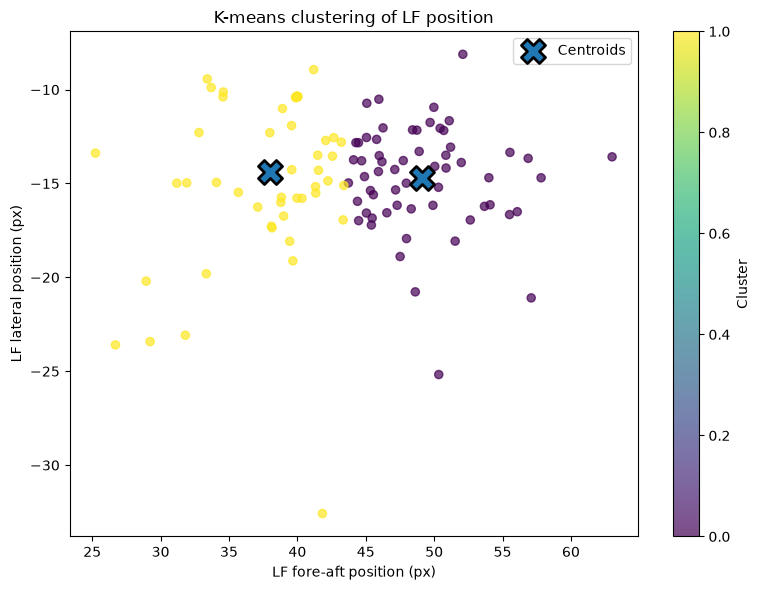

In [44]:

plt.figure(figsize=(8, 6))

scatter = plt.scatter(
    X_valid[:, 0],
    X_valid[:, 1],
    c=labels_valid,
    s=35,
    alpha=0.7,
    cmap="viridis"
)


plt.scatter(
    centroids[:, 0],
    centroids[:, 1],
    marker="X",
    s=300,
    edgecolor="black",
    linewidth=2,
    label="Centroids"
)


plt.xlabel(
    "LF fore-aft position (px)"
)

plt.ylabel(
    "LF lateral position (px)"
)

plt.title(
    "K-means clustering of LF position"
)

plt.legend()

plt.colorbar(
    scatter,
    label="Cluster"
)

plt.tight_layout()

plt.show()

determine which cluster is 

In [45]:
extended_cluster = np.argmax(
    centroids[:, 0]
)

retracted_cluster = np.argmin(
    centroids[:, 0]
)


print(
    "\nRetracted cluster:",
    retracted_cluster
)

print(
    "Extended cluster:",
    extended_cluster
)


Retracted cluster: 1
Extended cluster: 0


# remove short cluster

- 0 0 0 1 0 0 0
- If the "1" lasts only one frame,
- it is probably noise.

In [46]:
def remove_short_cluster_blips(
    labels,
    min_frames=3,
    missing_label=-1
):

    cleaned = labels.copy()

    changed = True

    while changed:

        changed = False

        i = 0

        while i < len(cleaned):

            state = cleaned[i]

            j = i + 1

            while (
                j < len(cleaned)
                and cleaned[j] == state
            ):

                j += 1


            run_length = j - i


            if (
                state != missing_label
                and run_length < min_frames
            ):

                left_state = (
                    cleaned[i - 1]
                    if i > 0
                    else missing_label
                )

                right_state = (
                    cleaned[j]
                    if j < len(cleaned)
                    else missing_label
                )


                if (
                    left_state == right_state
                    and left_state != missing_label
                ):

                    cleaned[i:j] = left_state

                    changed = True


            i = j


    return cleaned


cluster_labels_clean = remove_short_cluster_blips(
    cluster_labels,
    min_frames=MIN_CLUSTER_DURATION
)

# find extended - not extended 

In [47]:


cluster_step_frames = []


for frame in range(
    1,
    len(cluster_labels_clean)
):

    previous_state = (
        cluster_labels_clean[
            frame - 1
        ]
    )

    current_state = (
        cluster_labels_clean[
            frame
        ]
    )


    if (
        previous_state == retracted_cluster
        and
        current_state == extended_cluster
    ):

        # Require new state to persist
        # for at least MIN_CLUSTER_DURATION frames

        end_frame = min(
            frame + MIN_CLUSTER_DURATION,
            len(cluster_labels_clean)
        )


        if np.all(
            cluster_labels_clean[
                frame:end_frame
            ]
            == extended_cluster
        ):

            cluster_step_frames.append(
                frame
            )


cluster_step_frames = np.asarray(
    cluster_step_frames,
    dtype=int
)


print(
    "\nCandidate steps from clustering:",
    len(cluster_step_frames)
)

print(
    "Frames:",
    cluster_step_frames
)


Candidate steps from clustering: 3
Frames: [ 70 106 184]


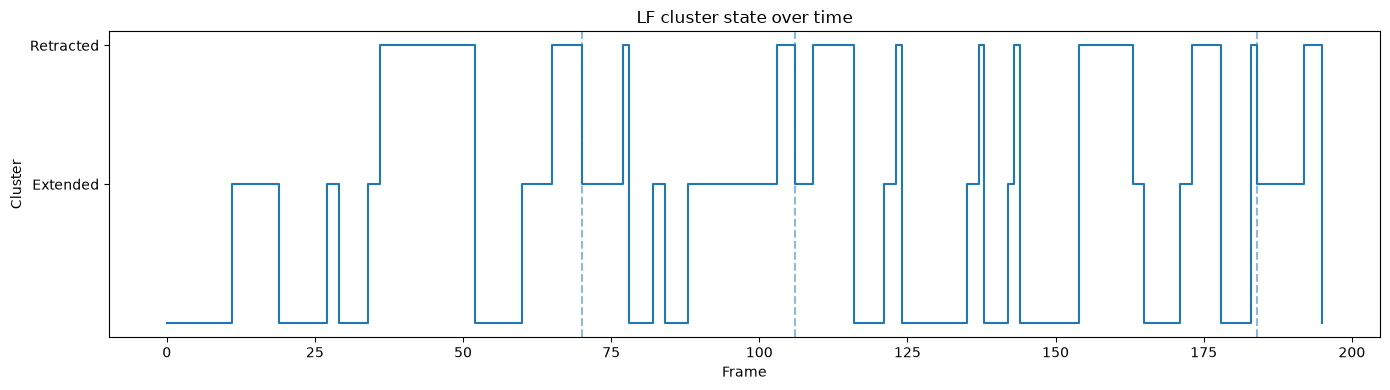

In [48]:


plt.figure(figsize=(14, 4))

plt.step(
    frames,
    cluster_labels_clean,
    where="post"
)


for frame in cluster_step_frames:

    plt.axvline(
        frame,
        linestyle="--",
        alpha=0.5
    )


plt.xlabel("Frame")

plt.ylabel("Cluster")

plt.title(
    "LF cluster state over time"
)

plt.yticks(
    [retracted_cluster, extended_cluster],
    ["Retracted", "Extended"]
)

plt.tight_layout()

plt.show()

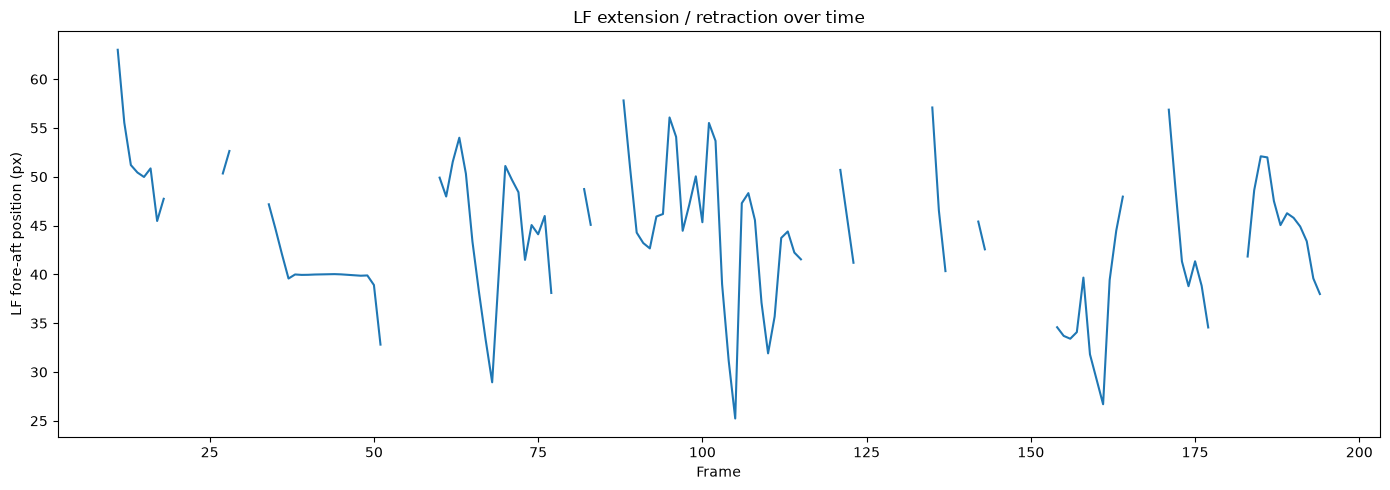

In [49]:
plt.figure(figsize=(14, 5))

plt.plot(
    frames,
    lf_fore_aft,
    linewidth=1.5
)

plt.xlabel("Frame")

plt.ylabel(
    "LF fore-aft position (px)"
)

plt.title(
    "LF extension / retraction over time"
)

plt.tight_layout()

plt.show()


Peak detection 

In [50]:
def find_peaks_with_nan_gaps(
    signal,
    prominence=10,
    distance=5
):

    signal = np.asarray(
        signal,
        dtype=float
    )

    valid = np.isfinite(
        signal
    )

    all_peaks = []


    start = 0


    while start < len(signal):

        # Skip invalid values

        while (
            start < len(signal)
            and not valid[start]
        ):

            start += 1


        if start >= len(signal):

            break


        end = start


        while (
            end < len(signal)
            and valid[end]
        ):

            end += 1


        segment = signal[
            start:end
        ]


        # Need enough points to detect a peak

        if len(segment) >= 3:

            peaks, _ = find_peaks(
                segment,
                prominence=prominence,
                distance=distance
            )

            all_peaks.extend(
                peaks + start
            )


        start = end


    return np.asarray(
        all_peaks,
        dtype=int
    )


peak_frames = find_peaks_with_nan_gaps(
    lf_fore_aft,
    prominence=PEAK_PROMINENCE,
    distance=PEAK_DISTANCE
)


print(
    "\nCandidate steps from peak detection:",
    len(peak_frames)
)

print(
    "Peak frames:",
    peak_frames
)



Candidate steps from peak detection: 5
Peak frames: [ 70  95 101 107 185]


Peak detection step

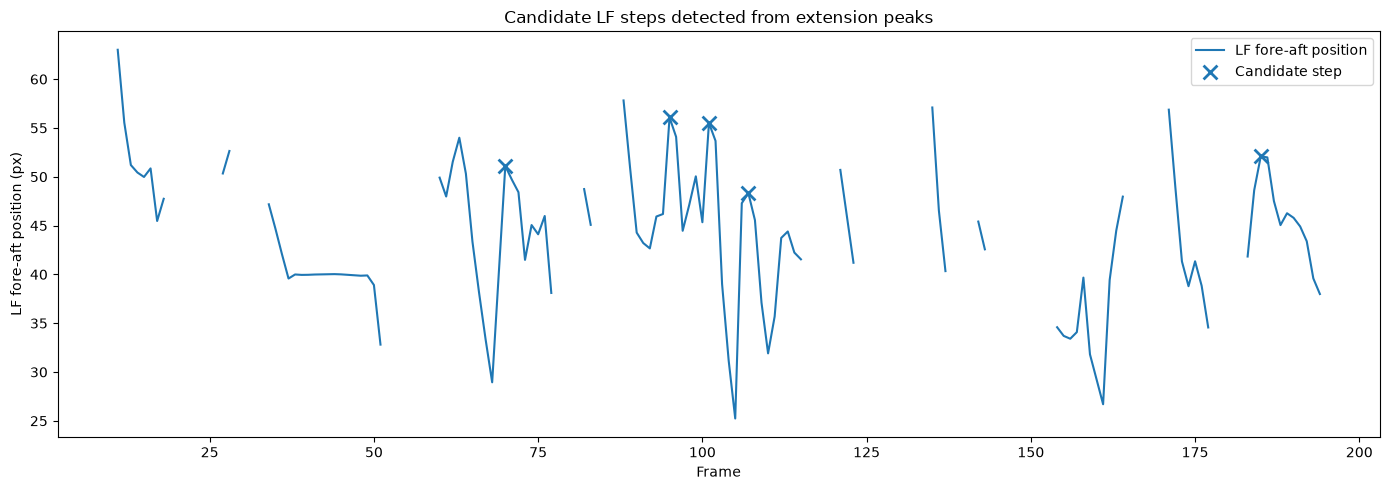

In [51]:
plt.figure(figsize=(14, 5))


plt.plot(
    frames,
    lf_fore_aft,
    label="LF fore-aft position"
)


plt.scatter(
    peak_frames,
    lf_fore_aft[
        peak_frames
    ],
    marker="x",
    s=100,
    linewidth=2,
    label="Candidate step"
)


plt.xlabel("Frame")

plt.ylabel(
    "LF fore-aft position (px)"
)

plt.title(
    "Candidate LF steps detected from extension peaks"
)

plt.legend()

plt.tight_layout()

plt.show()

Compare method on the same signal 

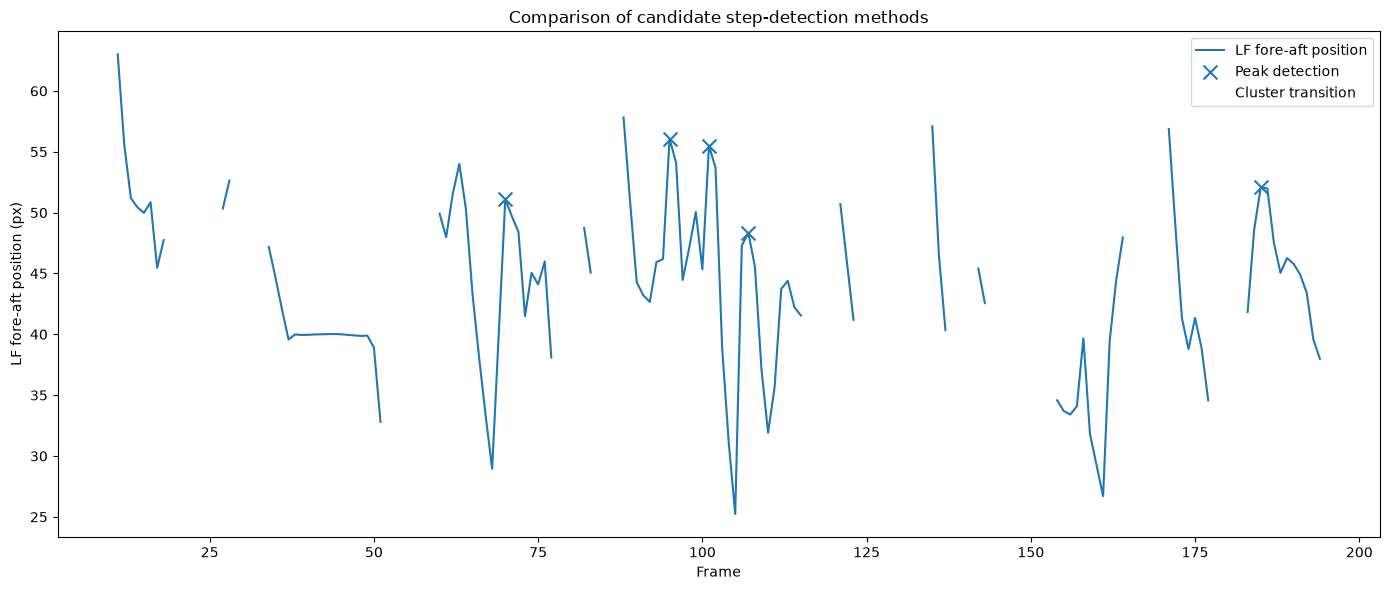

In [52]:
plt.figure(figsize=(14, 6))


plt.plot(
    frames,
    lf_fore_aft,
    label="LF fore-aft position",
    linewidth=1.5
)


# Peak detection

plt.scatter(
    peak_frames,
    lf_fore_aft[
        peak_frames
    ],
    marker="x",
    s=100,
    label="Peak detection"
)


# Cluster transitions

valid_cluster_steps = (
    cluster_step_frames[
        np.isfinite(
            lf_fore_aft[
                cluster_step_frames
            ]
        )
    ]
)


plt.scatter(
    valid_cluster_steps,
    lf_fore_aft[
        valid_cluster_steps
    ],
    marker="o",
    facecolors="none",
    s=120,
    linewidth=2,
    label="Cluster transition"
)


plt.xlabel("Frame")

plt.ylabel(
    "LF fore-aft position (px)"
)

plt.title(
    "Comparison of candidate step-detection methods"
)

plt.legend()

plt.tight_layout()


In [53]:
# Create label

In [54]:
results = pd.DataFrame(
    {
        "frame": frames,
        "time": time_values,
        "LF_fore_aft": lf_fore_aft,
        "LF_lateral": lf_lateral,
        "cluster_raw": cluster_labels,
        "cluster_clean": cluster_labels_clean,
        "cluster_step": False,
        "peak_step": False,
    }
)


results.loc[
    cluster_step_frames,
    "cluster_step"
] = True


results.loc[
    peak_frames,
    "peak_step"
] = True


print("\nResults:")

display(
    results.head(20)
)



Results:


,frame,time,LF_fore_aft,LF_lateral,cluster_raw,cluster_clean,cluster_step,peak_step
0,0,0,NaN,NaN,-1,-1,False,False
1,1,1,NaN,NaN,-1,-1,False,False
2,2,2,NaN,NaN,-1,-1,False,False
3,3,3,NaN,NaN,-1,-1,False,False
4,4,4,NaN,NaN,-1,-1,False,False
5,5,5,NaN,NaN,-1,-1,False,False
6,6,6,NaN,NaN,-1,-1,False,False
7,7,7,NaN,NaN,-1,-1,False,False
8,8,8,NaN,NaN,-1,-1,False,False
9,9,9,NaN,NaN,-1,-1,False,False


In [57]:



print("STEP DETECTION SUMMARY")


print(
    f"Frames analysed: {n_frames}"
)

print(
    f"Confidence threshold: "
    f"{CONFIDENCE_THRESHOLD}"
)

print(
    f"Maximum interpolated gap: "
    f"{MAX_INTERPOLATION_GAP} frames"
)

print(
    f"Cluster centroid distance: "
    f"{centroid_distance:.2f} px"
)

print(
    f"Silhouette score: "
    f"{silhouette:.3f}"
)

print(
    f"Candidate steps - clustering: "
    f"{len(cluster_step_frames)}"
)

print(
    f"Candidate steps - peaks: "
    f"{len(peak_frames)}"
)




STEP DETECTION SUMMARY
Frames analysed: 196
Confidence threshold: 0.7
Maximum interpolated gap: 3 frames
Cluster centroid distance: 11.17 px
Silhouette score: 0.437
Candidate steps - clustering: 3
Candidate steps - peaks: 5
